In [2]:
import pandas as pd
from sklearn.datasets import fetch_openml

df = fetch_openml(data_id=41214, as_frame=True).frame
print(df.shape)
df.head()


(678013, 12)


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   IDpol       678013 non-null  float64 
 1   ClaimNb     678013 non-null  int64   
 2   Exposure    678013 non-null  float64 
 3   Area        678013 non-null  category
 4   VehPower    678013 non-null  int64   
 5   VehAge      678013 non-null  int64   
 6   DrivAge     678013 non-null  int64   
 7   BonusMalus  678013 non-null  int64   
 8   VehBrand    678013 non-null  category
 9   VehGas      678013 non-null  str     
 10  Density     678013 non-null  int64   
 11  Region      678013 non-null  category
dtypes: category(3), float64(2), int64(6), str(1)
memory usage: 48.5 MB


In [21]:
df.describe()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
count,6.780130e+05,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000
mean,2.621857e+06,0.053247,0.528750,6.454631,7.044265,45.499122,59.761502,1792.422405
std,1.641783e+06,0.240117,0.364442,2.050906,5.666232,14.137444,15.636658,3958.646564
min,1.000000e+00,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,1.157951e+06,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,2.272152e+06,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000
75%,4.046274e+06,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1658.000000
max,6.114330e+06,16.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000


In [ ]:
print(df.dtypes) 

IDpol          float64
ClaimNb          int64
Exposure       float64
Area          category
VehPower         int64
VehAge           int64
DrivAge          int64
BonusMalus       int64
VehBrand      category
VehGas             str
Density          int64
Region        category
dtype: object


In [14]:
print(df.isna().sum())

IDpol         0
ClaimNb       0
Exposure      0
Area          0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Density       0
Region        0
dtype: int64


In [5]:
print(df["ClaimNb"].value_counts().sort_index(ascending=False))

ClaimNb
16         1
11         3
9          1
8          1
6          1
5          2
4          7
3         82
2       1784
1      32178
0     643953
Name: count, dtype: int64


In [20]:
print("Share of policies with at least one claim:", (df["ClaimNb"] > 0).mean())

Share of policies with at least one claim: 0.05023502499214617


In [35]:
print(df["Exposure"].describe())
print("Policies with Exposure > 1:", (df["Exposure"] > 1).sum())
print("Proportion of policies with Exposure > 1:", (df["Exposure"] > 1).sum() / len(df))
len(df)

count    678013.000000
mean          0.528750
std           0.364442
min           0.002732
25%           0.180000
50%           0.490000
75%           0.990000
max           2.010000
Name: Exposure, dtype: float64
Policies with Exposure > 1: 1224
Proportion of policies with Exposure > 1: 0.0018052751200935675


678013

In [25]:
#Claim frequency: naive vs. exposure-weighted
df["Frequency_naive"] = df["ClaimNb"] / df["Exposure"]
print(df.head())
naive = df["Frequency_naive"].mean()
print("Naive claim frequency:", naive)
weighted = df["ClaimNb"].sum() / df["Exposure"].sum()
print("Exposure-weighted claim frequency:", weighted)

   IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus  \
0    1.0        1      0.10    D         5       0       55          50   
1    3.0        1      0.77    D         5       0       55          50   
2    5.0        1      0.75    B         6       2       52          50   
3   10.0        1      0.09    B         7       0       46          50   
4   11.0        1      0.84    B         7       0       46          50   

  VehBrand     VehGas  Density Region  Frequency_naive  
0      B12  'Regular'     1217    R82        10.000000  
1      B12  'Regular'     1217    R82         1.298701  
2      B12   'Diesel'       54    R22         1.333333  
3      B12   'Diesel'       76    R72        11.111111  
4      B12   'Diesel'       76    R72         1.190476  
Naive claim frequency: 0.2639639532400521
Exposure-weighted claim frequency: 0.10070308464041305


DrivAgeBin
(17, 25]     38895
(25, 35]    149183
(35, 45]    170352
(45, 55]    161899
(55, 65]     90691
(65, 75]     48049
(75, 85]     17350
Name: count, dtype: int64
            claims      exposure
DrivAgeBin                      
(17, 25]      2841  16227.903263
(25, 35]      6662  69266.778075
(35, 45]      8397  87702.336287
(45, 55]      9256  89268.776408
(55, 65]      4748  51775.553261
(65, 75]      2873  30766.993476
(75, 85]      1167  12220.601867
            claims      exposure      freq
DrivAgeBin                                
(17, 25]      2841  16227.903263  0.175069
(25, 35]      6662  69266.778075  0.096179
(35, 45]      8397  87702.336287  0.095744
(45, 55]      9256  89268.776408  0.103687
(55, 65]      4748  51775.553261  0.091704
(65, 75]      2873  30766.993476  0.093379
(75, 85]      1167  12220.601867  0.095494


<Axes: title={'center': 'Claim frequency by driver age bin'}, xlabel='DrivAgeBin'>

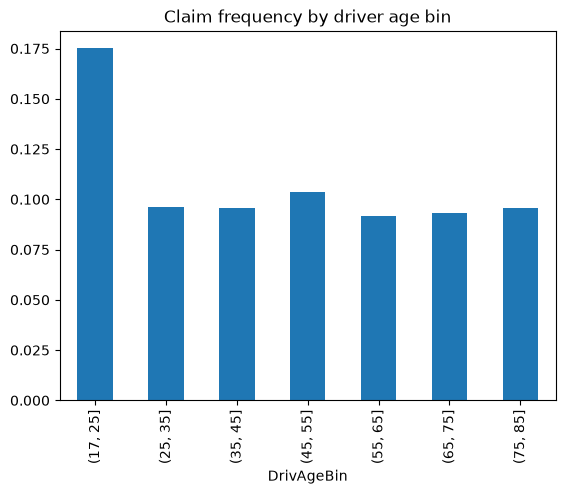

In [33]:
df["DrivAgeBin"] = pd.cut(df["DrivAge"], bins=[17, 25, 35, 45, 55, 65, 75, 85])    
print(df["DrivAgeBin"].value_counts().sort_index(ascending=True))
g = df.groupby("DrivAgeBin").agg(claims=("ClaimNb", "sum"), exposure=("Exposure", "sum"))
print(g)
g["freq"] = g["claims"] / g["exposure"]
print(g)
g["freq"].plot(kind="bar", title="Claim frequency by driver age bin")

1. Anteil der Policen mit mindestens einem Schaden: 5,023 %.
2. Policen mit Exposure > 1: 1.224 (0,18 %). Eine Exposure über einem Jahr ist im Beobachtungszeitraum unplausibel; diese Werte werden in der Bereinigung auf 1 begrenzt.
3. Exposure-gewichtete Schadenfrequenz: 10,07 % pro Versicherungsjahr (ca. 10 Schäden je 100 Vertragsjahre).
4. Die jüngsten Fahrer (18–25 Jahre) haben mit 17,51 % die höchste Schadenfrequenz, rund das 1,7-Fache des Gesamtdurchschnitts.